# Business Problem Statement

<image src="C:\Users\raj\OneDrive\Pictures\Screenshots\de1"></image>

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
from sklearn.model_selection import train_test_split 
from statsmodels.formula.api import ols 
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.metrics import r2_score , mean_squared_error 

In [3]:
df=pd.read_csv("delivery_time.csv")
df.sample(4)

,Delivery Time,Sorting Time
15,14.88,4
9,18.75,9
13,11.50,3
10,19.83,8


In [4]:
df.shape

(21, 2)

In [5]:
df.corr()

,Delivery Time,Sorting Time
Delivery Time,1.000000,0.825997
Sorting Time,0.825997,1.000000


In [6]:
df.kurtosis() 

Delivery Time    0.317960
Sorting Time    -1.148455
dtype: float64

In [7]:
df.skew()

Delivery Time    0.352390
Sorting Time     0.047115
dtype: float64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Delivery Time  21 non-null     float64
 1   Sorting Time   21 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 468.0 bytes


In [9]:
df.describe()

,Delivery Time,Sorting Time
count,21.000000,21.000000
mean,16.790952,6.190476
std,5.074901,2.542028
min,8.000000,2.000000
25%,13.500000,4.000000
50%,17.830000,6.000000
75%,19.750000,8.000000
max,29.000000,10.000000


In [10]:
df.isnull().sum()

Delivery Time    0
Sorting Time     0
dtype: int64

In [11]:
df.duplicated().sum()

0

# EDA

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Delivery Time  21 non-null     float64
 1   Sorting Time   21 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 468.0 bytes


In [13]:
df.columns

Index(['Delivery Time', 'Sorting Time'], dtype='object')

<Axes: xlabel='Delivery Time', ylabel='Count'>

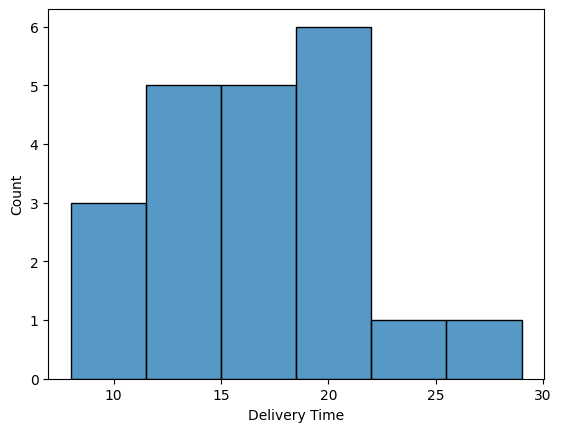

In [14]:
sns.histplot(df['Delivery Time'])

<Axes: xlabel='Delivery Time', ylabel='Density'>

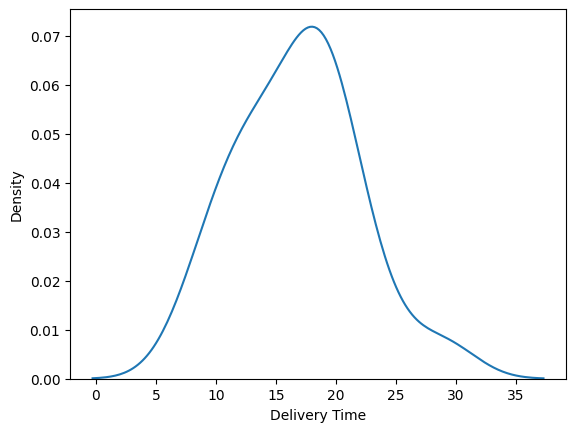

In [15]:
sns.kdeplot(df['Delivery Time'])

<Axes: >

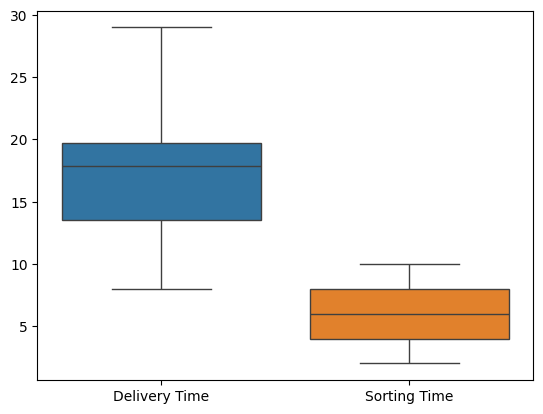

In [16]:
sns.boxplot(df)

<Axes: xlabel='Sorting Time', ylabel='Count'>

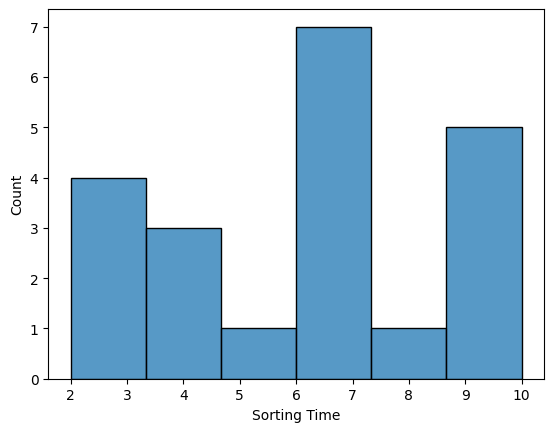

In [17]:
sns.histplot(df['Sorting Time'])

<Axes: xlabel='Sorting Time', ylabel='Density'>

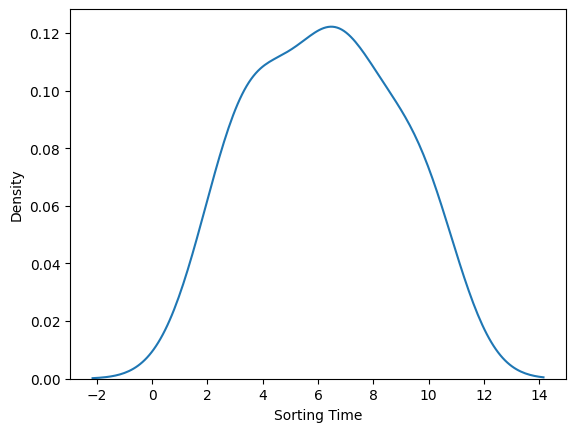

In [18]:
sns.kdeplot(df['Sorting Time'])

<Axes: >

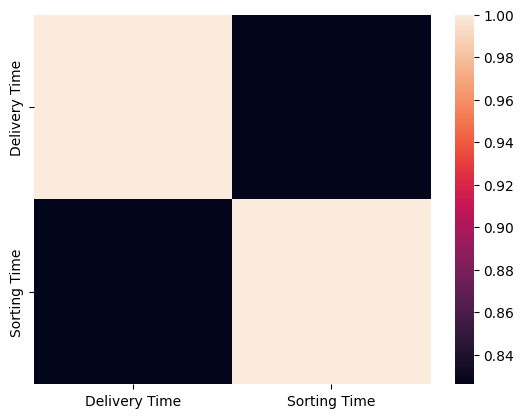

In [19]:
sns.heatmap(df.corr())

In [20]:
df.corr()

,Delivery Time,Sorting Time
Delivery Time,1.000000,0.825997
Sorting Time,0.825997,1.000000


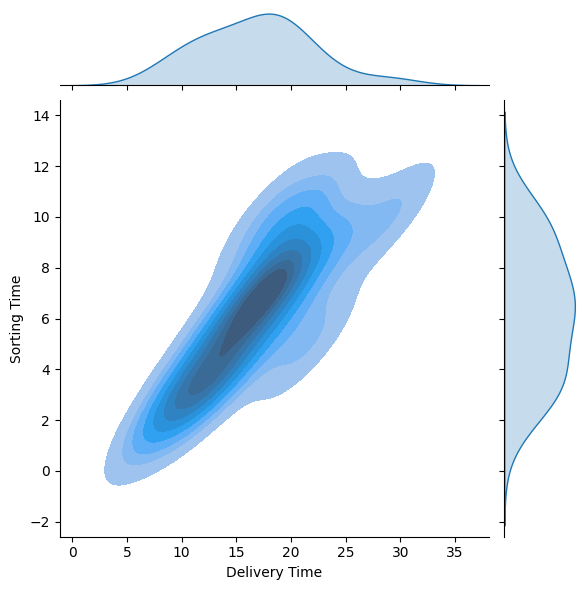

In [21]:
sns.jointplot(df,x='Delivery Time' ,y='Sorting Time',kind='kde',fill=True)

<Axes: xlabel='Delivery Time', ylabel='Sorting Time'>

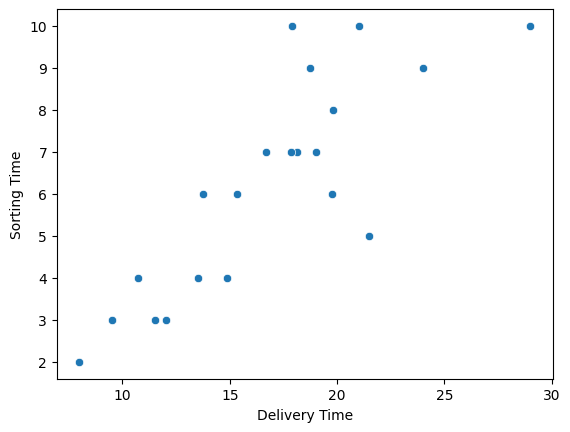

In [56]:
sns.scatterplot(df,x='Delivery Time',y='Sorting Time')

# Model Buliding and working 

In [57]:
df['X']=df['Delivery Time']
df['y']=df['Sorting Time']

In [25]:
# simple linear Regression 
lin1 = LinearRegression()
lin1.fit(df[['X']],df[['y']])

LinearRegression()

In [27]:
y_pre = lin1.predict(df[['X']])

In [28]:
r2_score(df['y'],y_pre)

0.6822714748417231

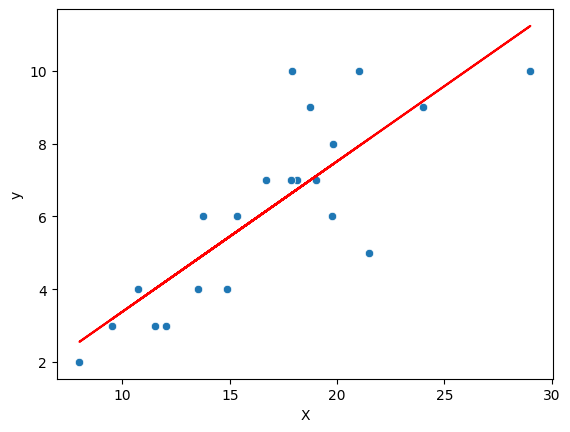

In [32]:
sns.scatterplot(df,x='X',y='y')
plt.plot(df['X'],y_pre,color='red')

In [33]:
lin2 =DecisionTreeRegressor()
lin2.fit(df[['X']],df[['y']])

DecisionTreeRegressor()

In [34]:
y_pre2=lin2.predict(df[['X']])

In [35]:
r2_score(df[['y']],y_pre2)

1.0

C:\Users\raj\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


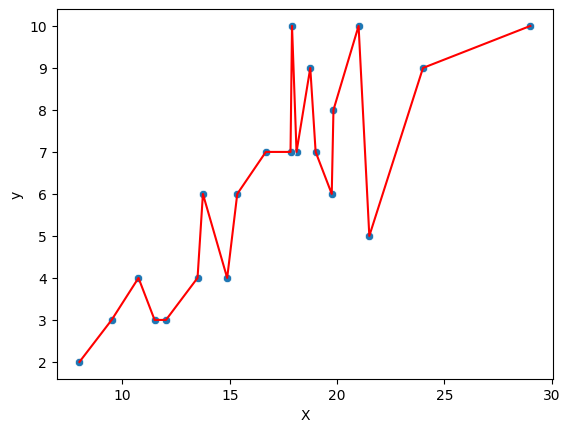

In [42]:
k = np.sort(df['X'].values)  # Convert to a sorted NumPy array
sns.scatterplot(df, x='X', y='y')
plt.plot(k, lin2.predict(k.reshape(-1, 1)), color='red')  # Ensure correct shape
plt.show()

In [38]:
# overfing model working the code is wrong to get to get

In [43]:
from sklearn.svm import SVR
lin3 =SVR()
lin3.fit(df[['X']],df[['y']])

C:\Users\raj\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [44]:
y_pre3=lin3.predict(df[['X']])
r2_score(df[['y']],y_pre3)

0.6499135101699991

C:\Users\raj\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


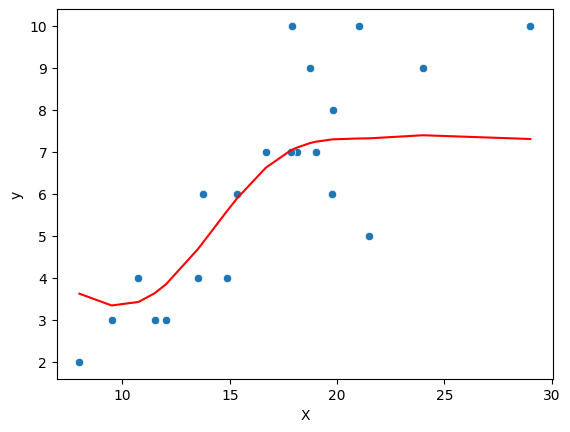

In [45]:
k = np.sort(df['X'].values)  # Convert to a sorted NumPy array
sns.scatterplot(df, x='X', y='y')
plt.plot(k, lin3.predict(k.reshape(-1, 1)), color='red')  # Ensure correct shape
plt.show()

In [49]:
import statsmodels.formula.api as smf
model=smf.ols('y~X',data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     40.80
Date:                Thu, 27 Feb 2025   Prob (F-statistic):           3.98e-06
Time:                        19:58:11   Log-Likelihood:                -36.839
No. Observations:                  21   AIC:                             77.68
Df Residuals:                      19   BIC:                             79.77
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7567      1.134     -0.667      0.5

In [52]:
predict1=model.predict(pd.DataFrame(df.X))
r2_score(df.y,predict1)

0.6822714748417231

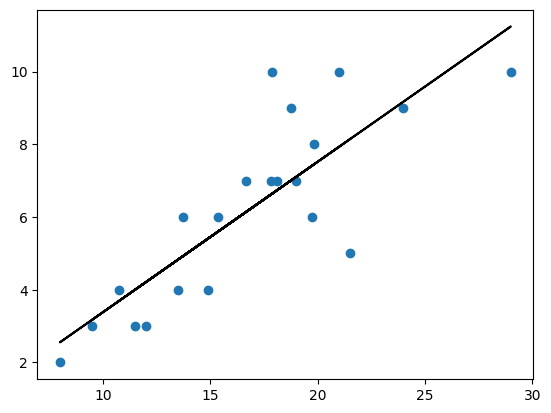

In [51]:
#regresion line 
plt.scatter(df[['X']],df.y)
plt.plot(df.X,predict1,'black')

In [53]:
from xgboost.sklearn import XGBRegressor 
lin3=XGBRegressor()